<a href="https://colab.research.google.com/github/mjcolebank/IPUQDT_Seminar_USC/blob/main/InvProb_UQ_Intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to inverse problem and UQ workflow: Spring Model

To begin, we start with general classes of linear or nonlinear ODE systems. We can write this succinctly as
\begin{align}
dx/dt = f(x,t;\theta), \ \ \ x(0)=x_0
\end{align}
where $x$ denotes the state variables that evolve in time $t$ according to the evolution operator $f(x,t;\theta)$ parameterized by $\theta$.

Our first prototypical model is the mass-spring-damper:
\begin{align}
m x'' + c x' + kx = F_0\cos(\omega_F t), \ \ x(0) = x_0, \ \ x'(0) = x_1 \ \ \ \rightarrow \text[M1]
\end{align}
where $m$ is the mass, $c$ is the dashpot coefficient, and $k$ is the spring stiffness. The right-hand side is a forcing function with magnitude $F_0$ and frequency $\omega_F$. This differential equation is second order, thus we convert it to a system of first order equations by defining $z = x'$. Then we have
\begin{align}
x' &= z, \ \ &x(0) = x_0 \\
z' & = -\frac{c}{m}z - \frac{k}{m}x + F_0\cos(\omega_F t), &z(0)=x_1 = z_0
\end{align}
where we let $x_1=z_0$ to make notation more intuitive.

Our second model is a model of disease spread, which includes susceptible-infected-recovered (SIR) dynamics:
\begin{align}
    \frac{dS}{dt} &= \mu R - \gamma I S  \ \ \ \rightarrow \text[M2a]\\
    \frac{dI}{dt} &=  \gamma I S - rI  \ \ \ \rightarrow \text[M2b]\\
    \frac{dR}{dt} &= r I - \mu R\ \ \ \rightarrow \text[M2c].
    \end{align}

where $\gamma$ is the infection rate, $r$ is the recovery rate, and $mu$ represents the collective birth and death rate. Each parameter is assumed to take values in the interval [0,1]. Assume that $\vec{\theta}$ are the model parameters and that the ODE system can be written more generally as $\dot{\vec{y}} = g(t,\vec{y};\vec{\theta})$. Here, for numerical reasons, we provide the relative populations $S^*=S/N$, $I^*=I/N$, and $R^*=R/N$.


<!--
or written concisely in matrix form
\begin{align}
        M x'' + C x' + K x = F(\theta_F)   
    \end{align}

where $M$ is a matrix with the mass values, $C$ is the matrix of dashpot coefficients, and $K$ is the matrix of stiffness parameters. Note that this problem is actually non-identifiable, as the problem can be written as
\begin{align}
        x'' + \tilde{C} x' + \tilde{K} x = 0   
    \end{align}
    where $\tilde{C} = M^{-1}C$ and $\tilde{K} = M^{-1}K$. Thus, we will assume that $M$ is known, but that $C$ and $K$ may be unknown (or convert the system to the second system). -->



# SECTION 0: Loading the libraries


In [1]:
# Run this if you are in Google Colab
!pip install numpy
!pip install matplotlib
!pip install scipy

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy import interpolate
from scipy.optimize import least_squares
from scipy import stats
from tqdm.notebook import tqdm
import time

# SECTION 1: Defining the models

In [4]:
def ODE_spring(y,t,params):
    x,z = y[:]
    m,c,k,F0,omega = params

    # RHS equations
    # velocity = dxdt
    dx = z
    # a = dzdt = F/m
    dz = -(c/m)*z - (k/m)*x + F0*np.cos(omega*t)
    return np.array((dx,dz))

In [5]:
# Note: we pass in the total population here as a constant
def ODE_SIR(y,t,params):
    # 3 states and 3x3=9 sensitivities
    S,I,R = y[:]
    mu,gamma,r = params

    # RHS equations
    # susceptible
    dSdt = mu*R -gamma*I*S
    # infected
    dIdt = gamma*I*S - r*I
    # recovered
    dRdt = r*I - mu*R

    return np.array((dSdt,dIdt,dRdt))

# SECTION 2: Define the baseline model parameters and time-interval for forward solutions

In [6]:
# The time intervals for the problems are distinct
tspace_spring = np.linspace(0,20,200)  # Seconds
tspace_SIR    = np.linspace(0,100,100) # Days

# Define the initial conditions
IC_spring = np.array((-5.0,0.0))
IC_SIR    = np.array((0.999,0.001,0.0))

# Define the parameters for the spring model
m      = 1.0
c      = 0.5
k      = 4.0
F0     = 1.0
omegaF = 3.0

param_spring = np.array((m,c,k,F0,omegaF))

# Define the parameters for the SIR model
mu    = 0.1
gamma = 0.7
r     = 0.2
param_SIR = np.array((mu,gamma,r))

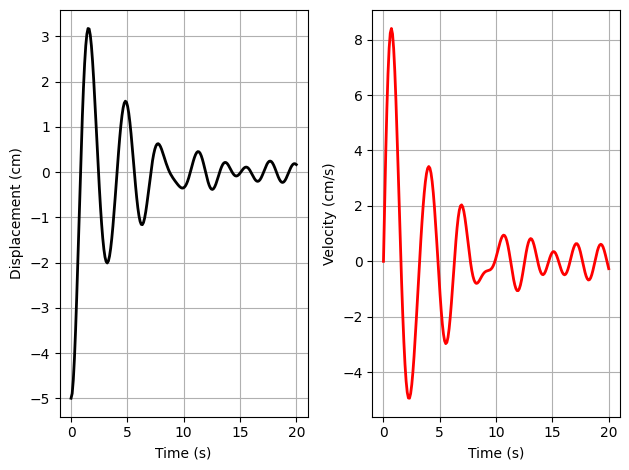

In [7]:
# Solve the spring model and plot the solutions

spring_sol = odeint(ODE_spring, IC_spring, tspace_spring, args=(param_spring,))
x,z = spring_sol.T

plt.figure()
plt.subplot(1,2,1)
plt.plot(tspace_spring,x,linewidth=2,color='black')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (cm)')
plt.grid()


plt.subplot(1,2,2)
plt.plot(tspace_spring,z,linewidth=2,color='red')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (cm/s)')
plt.grid()
plt.tight_layout()
plt.show()


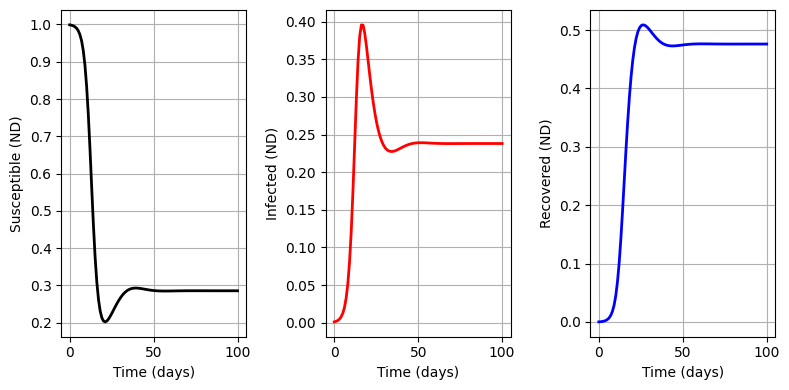

In [8]:
# Solve the SIR model and plot the solutions

SIR_sol = odeint(ODE_SIR, IC_SIR, tspace_SIR, args=(param_SIR,))
S,I,R = SIR_sol.T

plt.figure(figsize=(8,4))
plt.subplot(1,3,1)
plt.plot(tspace_SIR,S,linewidth=2,color='black')
plt.xlabel('Time (days)')
plt.ylabel('Susceptible (ND)')
plt.grid()

plt.subplot(1,3,2)
plt.plot(tspace_SIR,I,linewidth=2,color='red')
plt.xlabel('Time (days)')
plt.ylabel('Infected (ND)')
plt.grid()


plt.subplot(1,3,3)
plt.plot(tspace_SIR,R,linewidth=2,color='blue')
plt.xlabel('Time (days)')
plt.ylabel('Recovered (ND)')
plt.grid()


plt.tight_layout()
plt.show()


# SECTION 3: Sensitivity analysis

At its essence, sensitivity analysis asks how the parameters contribute to a quantity of interest (QoI). The choice of QoI almost entirely controls the sensitivity analysis results, as parameters may have different effects on different states or different time points of the trajectories.

The simplest rigorous method for sensitivity assessment is local sensitivity analysis, which quantifies model sensitivty through the derivative of the QoI. Let $q$ denote the QoI. Then a local sensitivity uses $dq/d\theta$, with $\theta$ representing the parameter. This can be approximated through several finite difference approaches, e.g.
\begin{align}
\frac{dq}{d\theta_i} \approx \frac{q(\theta+\Delta e_i) - q(\theta)}{\Delta} \ \ \ \text{or} \ \ \ \frac{dq}{d\theta_i} \approx \frac{q(\theta+\Delta e_i) - q(\theta-\Delta e_i)}{2\Delta}
\end{align}
where $e_i$ is a unit-vector in the $i$ th direction only. The most influential parameters are those with the largest effect.

In [9]:
# Define the centered-difference scheme

def cent_diff(q,f,h):
    f_base = f(q)
    n_param = np.size(q)
    n_outs  = np.size(f_base)
    sens = np.zeros((n_outs,n_param))
    perturb = np.eye(n_param)*h # Make an identity matrix and then take the columnes as unit vectors
    for i in range(n_param):
        f_fwd = f(q+perturb[:,i])
        f_bwd = f(q-perturb[:,i])
        sens[:,i] = (f_fwd-f_bwd)/(2.0*h)

    return sens


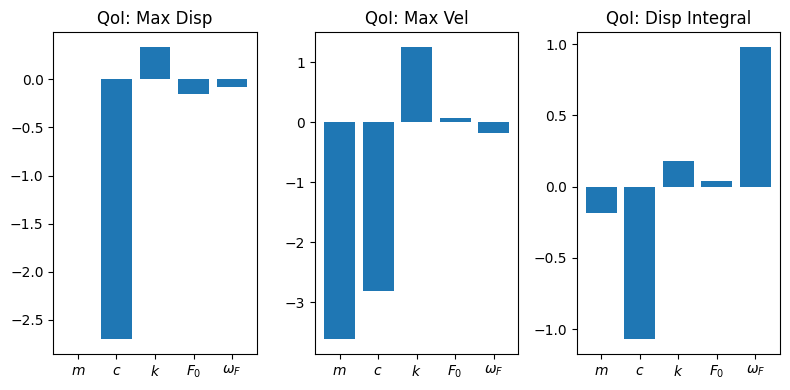

In [10]:
# Experiment with different QoI from the spring problem: the maximum displacement, maximum velocity, and the time integral of the displacement
def spring_maxdisplacement(q):
    spring_sol = odeint(ODE_spring, IC_spring, tspace_spring, args=(q,))
    x,z = spring_sol.T
    return np.max(x)

def spring_maxvelocity(q):
    spring_sol = odeint(ODE_spring, IC_spring, tspace_spring, args=(q,))
    x,z = spring_sol.T
    return np.max(z)

def spring_timeint(q):
    spring_sol = odeint(ODE_spring, IC_spring, tspace_spring, args=(q,))
    x,z = spring_sol.T
    return np.trapezoid(x,tspace_spring)

h = 1e-6
sens_spring_maxdisplacement = cent_diff(param_spring,spring_maxdisplacement,h)
sens_spring_maxvelocity = cent_diff(param_spring,spring_maxvelocity,h)
sens_spring_timeint = cent_diff(param_spring,spring_timeint,h)

spring_param_names = ['$m$','$c$','$k$','$F_0$','$\\omega_F$']
x_marks = np.arange(5)

plt.figure(figsize=(8,4))
plt.subplot(1,3,1)
plt.bar(x_marks,sens_spring_maxdisplacement.flatten())
plt.xticks(np.arange(5),labels=spring_param_names)
plt.title('QoI: Max Disp')

plt.subplot(1,3,2)
plt.bar(x_marks,sens_spring_maxvelocity.flatten())
plt.xticks(np.arange(5),labels=spring_param_names)
plt.title('QoI: Max Vel')

plt.subplot(1,3,3)
plt.bar(x_marks,sens_spring_timeint.flatten())
plt.xticks(np.arange(5),labels=spring_param_names)
plt.title('QoI: Disp Integral')
plt.tight_layout()
plt.show()

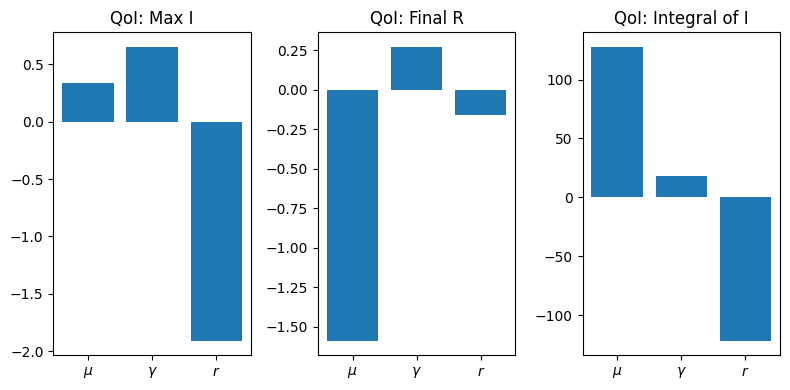

In [11]:
# Experiment with different QoI from the SIR problem: the maximum infected, final recovered, and the time integral of the infected
def SIR_maxI(q):
    SIR_sol = odeint(ODE_SIR, IC_SIR, tspace_SIR, args=(q,))
    S,I,R = SIR_sol.T
    return np.max(I)

def SIR_finalR(q):
    SIR_sol = odeint(ODE_SIR, IC_SIR, tspace_SIR, args=(q,))
    S,I,R = SIR_sol.T
    return R[-1]

def SIR_timeintI(q):
    SIR_sol = odeint(ODE_SIR, IC_SIR, tspace_SIR, args=(q,))
    S,I,R = SIR_sol.T
    return np.trapezoid(I,tspace_SIR)

h = 1e-6
sens_SIR_maxI = cent_diff(param_SIR,SIR_maxI,h)
sens_SIR_finalR = cent_diff(param_SIR,SIR_finalR,h)
sens_SIR_timeintI = cent_diff(param_SIR,SIR_timeintI,h)

SIR_param_names = ['$\\mu$','$\\gamma$','$r$']
x_marks = np.arange(3)

plt.figure(figsize=(8,4))
plt.subplot(1,3,1)
plt.bar(x_marks,sens_SIR_maxI.flatten())
plt.xticks(np.arange(3),labels=SIR_param_names)
plt.title('QoI: Max I')

plt.subplot(1,3,2)
plt.bar(x_marks,sens_SIR_finalR.flatten())
plt.xticks(np.arange(3),labels=SIR_param_names)
plt.title('QoI: Final R')

plt.subplot(1,3,3)
plt.bar(x_marks,sens_SIR_timeintI.flatten())
plt.xticks(np.arange(3),labels=SIR_param_names)
plt.title('QoI: Integral of I')
plt.tight_layout()
plt.show()

However, local sensitivity is based on derivatives and thus may be misleading as a GLOBAL metric of parmaeter effect. Consider the expanded spring example below (we 0-1 transform the sensitivities for ease of comparison)

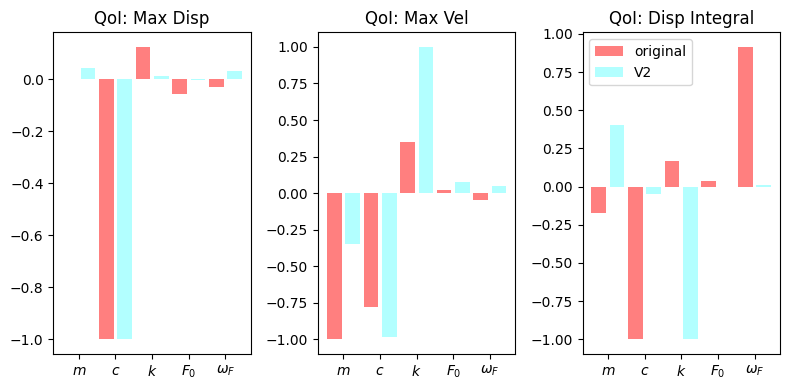

In [20]:
param_spring_V2 = [m*1,c*0.1,k*0.1,F0,omegaF]

sens_spring_maxdisplacement = cent_diff(param_spring,spring_maxdisplacement,h)
sens_spring_maxvelocity = cent_diff(param_spring,spring_maxvelocity,h)
sens_spring_timeint = cent_diff(param_spring,spring_timeint,h)

sens_spring_maxdisplacement = sens_spring_maxdisplacement/np.max(np.abs(sens_spring_maxdisplacement))
sens_spring_maxvelocity = sens_spring_maxvelocity/np.max(np.abs(sens_spring_maxvelocity))
sens_spring_timeint = sens_spring_timeint/np.max(np.abs(sens_spring_timeint))

sens_spring_maxdisplacement_V2 = cent_diff(param_spring_V2,spring_maxdisplacement,h)
sens_spring_maxvelocity_V2 = cent_diff(param_spring_V2,spring_maxvelocity,h)
sens_spring_timeint_V2 = cent_diff(param_spring_V2,spring_timeint,h)

sens_spring_maxdisplacement_V2 = sens_spring_maxdisplacement_V2/np.max(np.abs(sens_spring_maxdisplacement_V2))
sens_spring_maxvelocity_V2 = sens_spring_maxvelocity_V2/np.max(np.abs(sens_spring_maxvelocity_V2))
sens_spring_timeint_V2 = sens_spring_timeint_V2/np.max(np.abs(sens_spring_timeint_V2))


spring_param_names = ['$m$','$c$','$k$','$F_0$','$\\omega_F$']
x_marks = np.array((0,2,4,6,8))
x_marks2 = x_marks+1.0

plt.figure(figsize=(8,4))
plt.subplot(1,3,1)
plt.bar(x_marks,sens_spring_maxdisplacement.flatten(),alpha=0.5,color='red')
plt.bar(x_marks2,sens_spring_maxdisplacement_V2.flatten(),alpha=0.3,color='cyan')
plt.xticks(x_marks+0.5,labels=spring_param_names)
plt.title('QoI: Max Disp')

plt.subplot(1,3,2)
plt.bar(x_marks,sens_spring_maxvelocity.flatten(),alpha=0.5,color='red')
plt.bar(x_marks2,sens_spring_maxvelocity_V2.flatten(),alpha=0.3,color='cyan')
plt.xticks(x_marks+0.5,labels=spring_param_names)
plt.title('QoI: Max Vel')

plt.subplot(1,3,3)
plt.bar(x_marks,sens_spring_timeint.flatten(),alpha=0.5,color='red',label='original')
plt.bar(x_marks2,sens_spring_timeint_V2.flatten(),alpha=0.3,color='cyan',label='V2')
plt.xticks(x_marks+0.5,labels=spring_param_names)
plt.title('QoI: Disp Integral')
plt.legend()
plt.tight_layout()
plt.show()

# SECTION 4: Global Sensitivity analysis

The gold standard for global sensitivity analysis is variance-based sensitivity analysis, typically using Sobol' indices. Without getting into technical details, the Sobol' indices effectively measure how each parameter and its interactions contribute to the variance of the system.

The most common metrics are the first-order and the total-order Sobol' indices, denoted $S_i$ and $S_{T_i}$. The calculation of these indices require a good approximation of the variance of the system using monte carlo estimates, often on the order of 500-1000 per parameter.

We need to specify a prior distribution (e.g., Gaussian, uniform, Beta, etc) for the parameters, and then we can draw samples for running our simulator and approximating the variance.

In [23]:


for i in tqdm(range(100)):
    time.sleep(0.05)

  0%|          | 0/100 [00:00<?, ?it/s]

In [34]:
# We will assume independent uniform distributions for our parameters in this setting
def sobol_calculation(f,UB,LB,M):
    n_param = np.size(LB)
    # A = np.zeros((M, n_param))
    # B = np.zeros((M, n_param))
    A = np.random.uniform(LB,UB,(M,n_param))
    B = np.random.uniform(LB,UB,(M,n_param))
    # Now generate C, which is the matrix A with one column replaced by B
    C_cell = []
    for i in range(n_param):
        C = A.copy()
        C[:, i] = B[:, i]
        C_cell.append(C)
    # Lastly, initialize the output storage structure
    q_A = np.zeros((M, 1))
    q_B = np.zeros((M, 1))
    q_C = np.zeros((M, n_param))

    for j in tqdm(range(M), mininterval=0.5):
        time.sleep(0.05)
        q_A[j] = f(A[j, :])
        q_B[j] = f(B[j, :])

        for k in range(n_param):
            q_C[j,k] = f(C_cell[k][j, :])




    y_D = np.concatenate([q_A, q_B])
    f02 = ((1/(2*M))**2) * np.sum(y_D)**2

    S_i = np.zeros(n_param)
    ST_i = np.zeros(n_param)

    for k in range(n_param):
        S_i[k] = ((1/M) * (np.dot(q_B.T, q_C[:, k]) - np.dot(q_B.T, q_A))) / ((1/(2*M)) * np.dot(y_D.T, y_D) - f02)
        ST_i[k] = ((1/(2*M)) * (np.dot(q_A.T, q_A) - 2.0 * np.dot(q_A.T, q_C[:, k]) + np.dot(q_C[:, k].T, q_C[:, k]))) / ((1/(2*M)) * np.dot(y_D.T, y_D) - f02)

    return S_i, ST_i



# Note: the spring problem takes longer to run because the ODEs are stiffer.

In [51]:
LB_spring = [0.1,0.1,0.1,0.1,1.0]
UB_spring = [5.0,5.0,5.0,5.0,5.0]
M=5000
# Si_maxdisp,ST_maxdisp = sobol_calculation(spring_maxdisplacement,UB_spring,LB_spring,M)

In [36]:

# fig, ax = plt.subplots()
# label_pts = np.arange(5)
# Si_pts = np.arange(5)-0.15
# STi_pts = np.arange(5)+0.15
# ax.bar(Si_pts, Si_maxdisp, label='First-order',width=0.25)
# ax.bar(STi_pts, ST_maxdisp, label='Total-order',width=0.25)
# ax.set_xticks(label_pts)
# ax.set_xticklabels(spring_param_names)
# ax.legend()
# ax.set_title('Sobol: Max Disp')


In [37]:
LB_SIR = [0.01,0.01,0.01]
UB_SIR = [1.0,1.0,1.0]
M=5000
Si_maxI,ST_maxI = sobol_calculation(SIR_maxI,UB_SIR,LB_SIR,M)

  0%|          | 0/5000 [00:00<?, ?it/s]

/tmp/ipykernel_2420/1200122869.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S_i[k] = ((1/M) * (np.dot(q_B.T, q_C[:, k]) - np.dot(q_B.T, q_A))) / ((1/(2*M)) * np.dot(y_D.T, y_D) - f02)
/tmp/ipykernel_2420/1200122869.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ST_i[k] = ((1/(2*M)) * (np.dot(q_A.T, q_A) - 2.0 * np.dot(q_A.T, q_C[:, k]) + np.dot(q_C[:, k].T, q_C[:, k]))) / ((1/(2*M)) * np.dot(y_D.T, y_D) - f02)


Text(0.5, 1.0, 'Sobol: Max I')

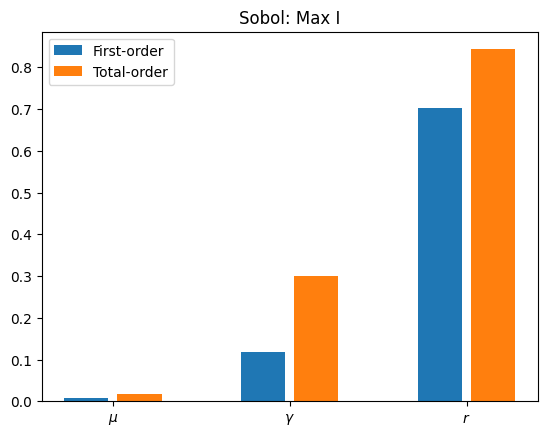

In [38]:

fig, ax = plt.subplots()
label_pts = np.arange(3)
Si_pts = np.arange(3)-0.15
STi_pts = np.arange(3)+0.15
ax.bar(Si_pts, Si_maxI, label='First-order',width=0.25)
ax.bar(STi_pts, ST_maxI, label='Total-order',width=0.25)
ax.set_xticks(label_pts)
ax.set_xticklabels(SIR_param_names)
ax.legend()
ax.set_title('Sobol: Max I')


## All of the sections from here are using the spring model. Followig this will be the SIR model

# SECTION 6: Inference and calibration

Once we know that parameters are influential on our model behavior, we can replace our QoI with an objective/cost/loss function. Then our goal is to find the minimizer
\begin{align}
\hat{\theta} = \arg\min_\theta J(\theta)
\end{align}
where, for example, $J(\theta) = r^\top(\theta) r$ is the sum of squared residuals with $r = (y_1-m(t_1;\theta),y_2-m(t_2;\theta), \dots, y_D-m(t_D;\theta))$, where $D$ is the number of data points.

In the above formulation, we implicitly assume a statistical model of the form
\begin{align}
y_i = m(t_i;\theta) + \varepsilon_i, \ \ \ \varepsilon_i \sim \mathcal{N}(0,\sigma^2)
\end{align}
where $m(t_i;\theta)$ is our model output at time $t_i$ and $\varepsilon_i$ is the corresponding measurement noise. We often assume this noise is independent and identically distributed Gaussian noise, with variance $\sigma^2$.

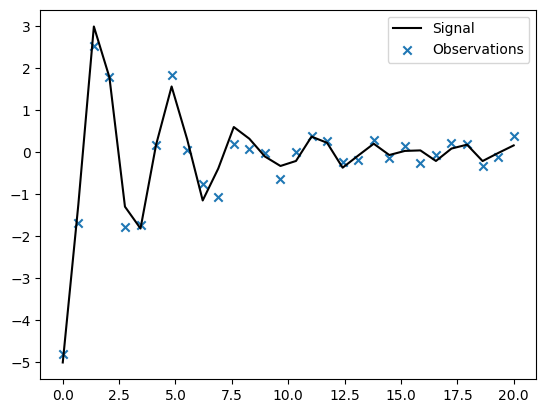

In [42]:
# Generate pseudo data from Spring problem for inference
param_spring_data = [m,c,k,F0,omegaF]
tdata_spring = np.linspace(0,tspace_spring[-1],30)
spring_sol = odeint(ODE_spring,IC_spring,tdata_spring,args=(param_spring_data,))
xtrue,vtrue = spring_sol.T

xdata = xtrue + np.random.normal(loc=0.0,scale=0.3,size = len(tdata_spring))

plt.figure()
plt.plot(tdata_spring,xtrue,color='black',label='Signal')
plt.scatter(tdata_spring,xdata,marker='x',label='Observations')
plt.legend()
plt.show()


In [43]:
# Define an objective function for solving the least squares problem
def spring_OLS(q):
    model_eval = odeint(ODE_spring,IC_spring,tdata_spring,args=(q,))
    xeval,veval = model_eval.T

    residual = xdata - xeval
    return residual



In [57]:
# Now, we can solve the least squares inverse problem:
spring_x0 = np.array((2.5,0.3,2.0,1.5,5.0))

result = least_squares(fun=spring_OLS,x0=spring_x0,bounds=(0.1,5.0))


In [58]:
# Now print the results...
print(f'Esimtated Parameters: {result.x}')
print(f'True Parameters: {param_spring_data}')

Esimtated Parameters: [0.99638509 0.50642712 3.94361995 1.9493024  4.43926911]
True Parameters: [1.0, 0.5, 4.0, 1.0, 3.0]


# SECTION 7: Identifiability

Identifiability refers to whether a parameter can be uniquely determined from data. Note that the spring problem is NOT identifiable. Why? Because the mass, $m$, is never found isolated from the spring stiffness $k$ or the dashpot term $c$.

We have two choices: fix the mass OR we can define a new parameter set, $\{\tilde{c},\tilde{k},F_0,\omega_F\}$ where $\tilde{c} = c/m$ and $\tilde{k} = k/m$.

We often fix parameters, so we will do the former for now.

How can we tell if parameters are identifiable? One quick (but not robust) way to do this is by investigating the local-sensitivity. If two parameters have nearly identical local-sensitivities, then this suggest their net affect on the quantity of interest is non-identifiable. This is largely related to the idea that the Hessian is poorly conditioned or singular.

For the spring, let's look at the time-series displacement at the measurement locations as our quantity. We will construct the Fisher-information matrix (FIM), defined as $S^\top S = F$ where $S$ is the sensitivity, is effectively an approximation of the Hessian of our problem. The condition number of this matrix will help identify if there are any linearly-dependent parameters in our system.

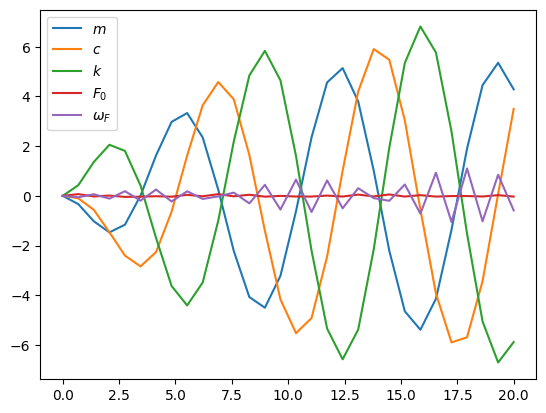




Condition Number of FIM: 19719282337836.9


In [59]:
def spring_timeseries(q):
    spring_sol = odeint(ODE_spring, IC_spring, tdata_spring, args=(q,))
    x,z = spring_sol.T
    return x

S_spring = cent_diff(q=spring_x0,f=spring_timeseries,h=1e-6)


plt.figure()
plt.plot(tdata_spring,S_spring)
plt.legend(spring_param_names)
plt.show()

F = np.matmul(S_spring.T,S_spring)
print(f"\n\n\nCondition Number of FIM: {np.linalg.cond(F)}")


In [61]:
# Now, we consider fixing $m$ and inferring our other parameters
def spring_OLS_fixM(q,m_fix):
  # We just pass in the mass as a fixed term
    full_param = np.insert(q,0,m_fix)
    model_eval = odeint(ODE_spring,IC_spring,tdata_spring,args=(full_param,))
    xeval,veval = model_eval.T

    residual = xdata - xeval
    return residual


# Now, we can solve the least squares inverse problem:
spring_x0 = np.array((0.1,2.0,1.5,5.0))
m0 = 1.0
result_fixM = least_squares(fun=spring_OLS_fixM,x0=spring_x0,args=(m0,),bounds=(0.1,5.0))
print(f'Fixed and Estimated Parameters: {m0,result_fixM.x}')
print(f'True Parameters: {param_spring_data}')
print(f'Nonidentifiable estimates: {result.x}')

print(f'Final Cost: {result_fixM.cost}')

Fixed and Estimated Parameters: (1.0, array([0.51119884, 3.95826768, 0.47423581, 3.00989841]))
True Parameters: [1.0, 0.5, 4.0, 1.0, 3.0]
Nonidentifiable estimates: [0.99638509 0.50642712 3.94361995 1.9493024  4.43926911]
Final Cost: 0.9216961941972155


In [64]:
# Last thing: F0 and omega seem to be non-influential. Let's only estimate the last three
def spring_OLS_fixM_F_freq(q,m_fix,F_fix,omega_fix):
    full_param = np.array((m_fix,q[0],q[1],F_fix,omega_fix))
    model_eval = odeint(ODE_spring,IC_spring,tdata_spring,args=(full_param,))
    xeval,veval = model_eval.T

    residual = xdata - xeval
    return residual


# Now, we can solve the least squares inverse problem:
spring_x0 = np.array((0.1,2.0))
m0 = 1.0
F0 = 1.0
omega0 = 3.0
result_fixM_F_omega = least_squares(fun=spring_OLS_fixM_F_freq,x0=spring_x0,args=(m0,F0,omega0,),bounds=(0.1,5.0))
print(f'Fixed and Estimated Parameters: {m0,result_fixM_F_omega.x,F0,omega0}')
print(f'True Parameters: {param_spring_data}')
print(f'Nonidentifiable estimates: {result.x}')

print(f'Final Cost: {result_fixM.cost}')

Fixed and Estimated Parameters: (1.0, array([0.50130208, 3.95788786]), 1.0, 3.0)
True Parameters: [1.0, 0.5, 4.0, 1.0, 3.0]
Nonidentifiable estimates: [0.99638509 0.50642712 3.94361995 1.9493024  4.43926911]
Final Cost: 0.9216961941972155


## Now, lets do the same thing for the SIR model. Here, we only observe infected

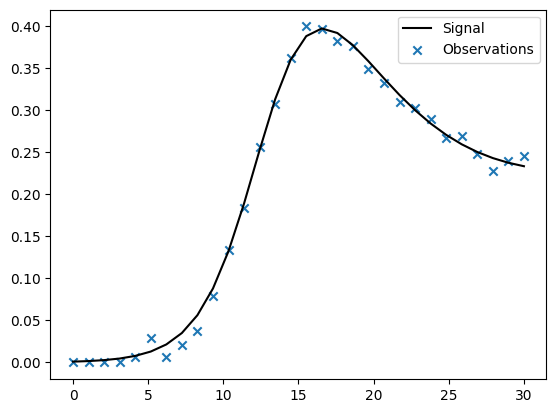

In [170]:
# Generate pseudo data from Spring problem for inference
param_SIR_data = [mu,gamma,r]
tdata_SIR = np.linspace(0,30,30)
SIR_sol = odeint(ODE_SIR,IC_SIR,tdata_SIR,args=(param_SIR_data,))
Strue,Itrue,Rtrue = SIR_sol.T

var_eps = 0.01
xdata = Itrue + np.random.normal(loc=0.0,scale=var_eps,size = len(tdata_SIR))
xdata = np.maximum(xdata,0.0)
plt.figure()
plt.plot(tdata_SIR,Itrue,color='black',label='Signal')
plt.scatter(tdata_SIR,xdata,marker='x',label='Observations')
plt.legend()
plt.show()


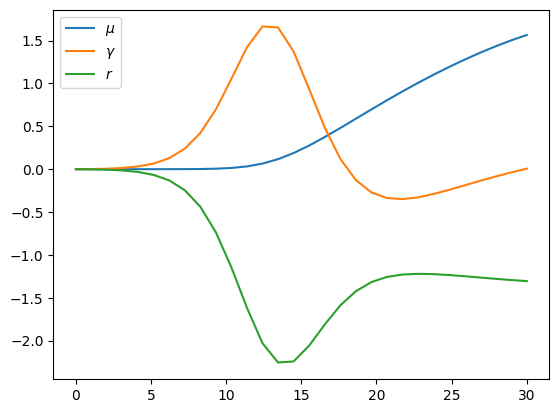




Condition Number of FIM: 55.52844913855512


In [171]:
# Before we do any inference, let's look at the Fisher information matrix
def infected_timeseries(q):
    SIR_sol = odeint(ODE_SIR, IC_SIR, tdata_SIR, args=(q,))
    S,I,R = SIR_sol.T
    return I

SIR_x0 = np.array((0.1,0.7,0.2))
S_infect = cent_diff(q=SIR_x0,f=infected_timeseries,h=1e-6)


plt.figure()
plt.plot(tdata_SIR,S_infect)
plt.legend(SIR_param_names)
plt.show()

F = np.matmul(S_infect.T,S_infect)
print(f"\n\n\nCondition Number of FIM: {np.linalg.cond(F)}")


Estimated Parameters: [0.10328966 0.70279756 0.2029074 ]
True Parameters: [0.1, 0.7, 0.2]
Final Cost: 0.0010759168805994485


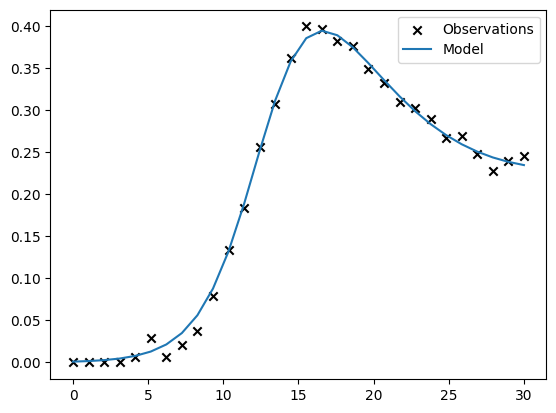

In [172]:
def SIR_OLS(q):
    model_eval = odeint(ODE_SIR,IC_SIR,tdata_SIR,args=(q,))
    Seval,Ieval,Reval = model_eval.T

    residual = xdata - Ieval
    return residual


# Now, we can solve the least squares inverse problem:
SIR_x0 = np.array((0.1,0.7,0.2))

result_SIR = least_squares(fun=SIR_OLS,x0=SIR_x0,bounds=(0.001,1.0))
opt_SIR_param = result_SIR.x
print(f'Estimated Parameters: {opt_SIR_param}')
print(f'True Parameters: {param_SIR_data}')
print(f'Final Cost: {result_SIR.cost}')

model_opt_sol = odeint(ODE_SIR,IC_SIR,tdata_SIR,args=(opt_SIR_param,))
I_opt = model_opt_sol[:,1]
plt.figure()
plt.scatter(tdata_SIR,xdata,marker='x',color='black',label='Observations')
plt.plot(tdata_SIR,I_opt,label='Model')
plt.legend()
plt.show()

# SECTION 8: Uncetainty Quantification

I typically go a Bayesian route, but to save time here, we cover the asymptotic frequentist approach. Central limit theorem (law of large numbers) can give us asymptotic properties due to the Guassian nature of the measurement errors. In particular, given some nonlinear model $m(t;\theta)$ with observations $y_i$ and measurement error $\varepsilon_i$, we can calculate the approximate parameter confidence intervals

\begin{align}
CI_\theta^{1-\alpha} = \left\{\hat{\theta}\pm t^{1-\alpha}_{N-p}\cdot \sqrt{\sigma^2_\varepsilon \text{diag}(S^\top S)^{-1}}\right\}, \ \ \ \sigma^2_\varepsilon = \frac{1}{N-p}r(\hat{\theta})^\top r(\hat{\theta})
\end{align}

where $r(\hat{\theta})$ is the residual vector at the optimal parameter value, $N$ is the number of observations, and $p$ is the number of parameters. Confidence and prediction intervals for the output can also be constructed:

\begin{align}
CI_m^{1-\alpha}(t_i) = \left\{m(t_i;\hat{\theta})\pm t^{1-\alpha}_{N-p}\cdot \sqrt{\sigma^2_\varepsilon G^\top\text{diag}(S^\top S)^{-1}}G\right\}, \ \ \ G = \frac{\partial m}{\partial \theta}_{t_i}
\end{align}

\begin{align}
PI_m^{1-\alpha}(t_i) = \left\{m(t_i;\hat{\theta})\pm t^{1-\alpha}_{N-p}\cdot \sqrt{\sigma^2_\varepsilon +\sigma^2_\varepsilon G^\top\text{diag}(S^\top S)^{-1}}G\right\}, \ \ \ G = \frac{\partial m}{\partial \theta}_{t_i}
\end{align}



We will just employ this for the SIR model here.

In [173]:
tval = stats.t.ppf(0.95,len(tdata_SIR)-3)
S_infect_opt = cent_diff(q=opt_SIR_param,f=infected_timeseries,h=1e-6)
F_opt = np.matmul(S_infect_opt.T,S_infect_opt)
residual_opt = SIR_OLS(opt_SIR_param)
sigma2_opt = np.matmul(residual_opt.T,residual_opt)/(len(tdata_SIR)-3)

# parameter confidence intervals
CI_plus = opt_SIR_param + tval*np.sqrt(sigma2_opt*np.diag(np.linalg.inv(F_opt)))
CI_minus = opt_SIR_param - tval*np.sqrt(sigma2_opt*np.diag(np.linalg.inv(F_opt)))
print(f'Parameter Confidence Intervals:\n upper: {CI_minus} \n opt:   {opt_SIR_param} \n lower: {CI_plus}')

Parameter Confidence Intervals:
 upper: [0.09351682 0.69317916 0.19591831] 
 opt:   [0.10328966 0.70279756 0.2029074 ] 
 lower: [0.1130625  0.71241595 0.20989649]


In [177]:
# Now generate confidence/prediction intervals for the model response
tforecast = np.linspace(0,100,200) # We can look to the future

def infected_forecast(q):
    SIR_sol = odeint(ODE_SIR, IC_SIR, tforecast, args=(q,))
    S,I,R = SIR_sol.T
    return I

model_forecast = odeint(ODE_SIR,IC_SIR,tforecast,args=(opt_SIR_param,))
I_forecast = model_forecast[:,1]
Sens_forecast = cent_diff(q=opt_SIR_param,f=infected_forecast,h=1e-6)


Y_CI_plus = np.zeros((len(tforecast),1))
Y_CI_minus = np.zeros((len(tforecast),1))
Y_PI_plus = np.zeros((len(tforecast),1))
Y_PI_minus = np.zeros((len(tforecast),1))
Y_SE       = np.zeros((len(tforecast),1))
invF_diag = np.diag(np.linalg.inv(F_opt))
G = Sens_forecast.copy()
for i in range(len(tforecast)):
  Y_CI_plus[i] = I_forecast[i] + tval*np.sqrt(sigma2_opt*np.matmul(G[i,:].T,invF_diag*G[i,:]))
  Y_CI_minus[i] = I_forecast[i] - tval*np.sqrt(sigma2_opt*np.matmul(G[i,:].T,invF_diag*G[i,:]))
  Y_PI_plus[i] = I_forecast[i] + tval*np.sqrt(sigma2_opt+sigma2_opt*np.matmul(G[i,:].T,invF_diag*G[i,:]))
  Y_PI_minus[i] = I_forecast[i] - tval*np.sqrt(sigma2_opt+sigma2_opt*np.matmul(G[i,:].T,invF_diag*G[i,:]))
  Y_SE[i] = np.sqrt(sigma2_opt*np.matmul(G[i,:].T,invF_diag*G[i,:]))





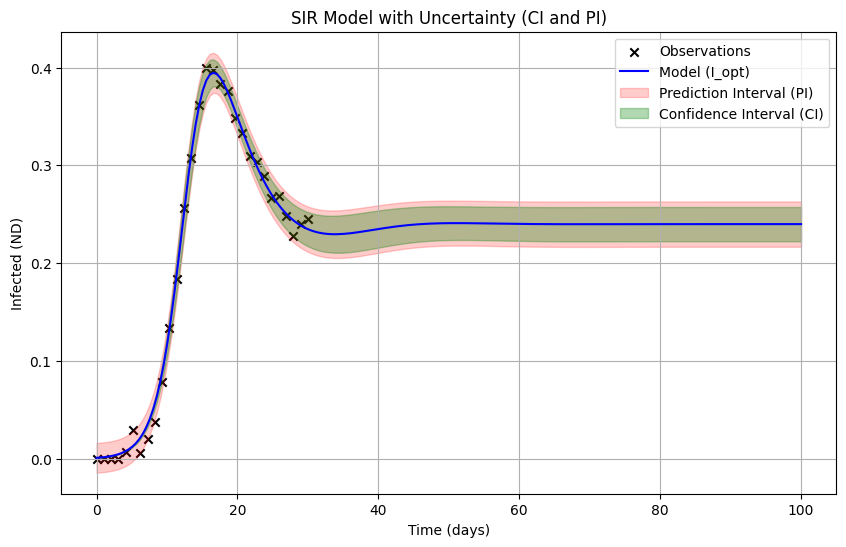

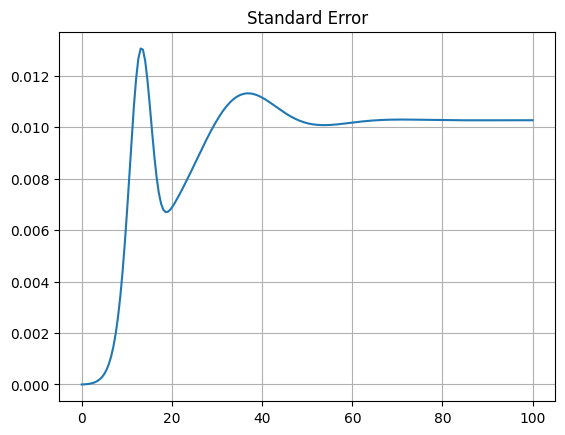

In [178]:
plt.figure(figsize=(10, 6))
plt.scatter(tdata_SIR, xdata, marker='x', color='black', label='Observations')
plt.plot(tforecast, I_forecast, label='Model (I_opt)', color='blue')

# Shade Prediction Interval (PI) - wider band
plt.fill_between(tforecast, Y_PI_minus.flatten(), Y_PI_plus.flatten(), color='red', alpha=0.2, label='Prediction Interval (PI)')

# Shade Confidence Interval (CI) - narrower band
plt.fill_between(tforecast, Y_CI_minus.flatten(), Y_CI_plus.flatten(), color='green', alpha=0.3, label='Confidence Interval (CI)')

plt.xlabel('Time (days)')
plt.ylabel('Infected (ND)')
plt.title('SIR Model with Uncertainty (CI and PI)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(tforecast,Y_SE)
plt.title('Standard Error')
plt.grid(True)
plt.show()